<div style="text-align: center; font-family: Arial; line-height: 1.5;">

# Instituto Internacional de Aguascalientes

## Maestría en Inteligencia Artificial para la Transformación Digital

### Programa: Aprendizaje Inteligente

<br><br>

# Práctica: análisis, implementación y prueba del algoritmo del perceptrón de Frank Rosenblatt aplicado a la selección preliminar de candidatos para entrevista laboral.

<br><br>

**Alumno:** Antonio Nicolás Toro González  
**Tutor:** Dr. Francisco Javier Luna Rosas

<br><br><br>

## Junio 2026

</div>

## 1. Marco teórico

### 1.1 Conceptos generales de Machine Learning

El aprendizaje de máquina, o *machine learning*, es una rama de la inteligencia artificial que estudia algoritmos capaces de mejorar su desempeño a partir de la experiencia. A diferencia de la programación tradicional, donde las reglas son definidas explícitamente por el programador, en *machine learning* el sistema aprende patrones desde datos y utiliza esos patrones para realizar predicciones, clasificaciones o decisiones.

Una definición clásica establece que un programa aprende de una experiencia **E**, respecto a una tarea **T** y una medida de desempeño **P**, si su desempeño en la tarea mejora con la experiencia. Esta idea permite entender el aprendizaje como un proceso medible: el sistema recibe datos, realiza una tarea y se evalúa mediante una métrica de desempeño.

Los antecedentes del aprendizaje de máquina se relacionan con la inteligencia artificial, la estadística, la cibernética y los primeros modelos inspirados en el sistema nervioso. Durante las décadas de 1940 a 1960 surgieron modelos neuronales artificiales que buscaban explicar cómo una máquina podía reconocer patrones y modificar su comportamiento. En este contexto, el perceptrón de Frank Rosenblatt, propuesto en 1958, se considera uno de los primeros modelos de aprendizaje automático y un antecedente directo de las redes neuronales artificiales.

### 1.2 El perceptrón de Frank Rosenblatt

El perceptrón es un modelo simple de clasificación binaria. Recibe entradas numéricas, les asigna pesos, calcula una suma ponderada y aplica una función de activación para producir una salida. De forma general, calcula:

$$
z = w \cdot x + b
$$

donde **x** representa el vector de entradas, **w** el vector de pesos y **b** el sesgo. Después aplica una función escalón:

$$
y =
\begin{cases}
1, & \text{si } z \geq 0 \\
0, & \text{si } z < 0
\end{cases}
$$

El aprendizaje ocurre cuando el modelo compara su predicción con la salida real y ajusta sus pesos si existe error:

$$
w_i = w_i + \eta (y - \hat{y})x_i
$$

El sesgo se actualiza mediante:

$$
b = b + \eta (y - \hat{y})
$$

donde **η** es la tasa de aprendizaje, **y** es la salida real y **ŷ** es la predicción del modelo.

La importancia del perceptrón radica en que muestra de forma clara cómo un modelo puede aprender una frontera de decisión a partir de ejemplos. Sin embargo, su principal limitación es que solo puede resolver problemas linealmente separables; por ello, no puede resolver correctamente problemas no lineales como XOR sin utilizar capas adicionales.


## 2. Motivación de la práctica

**Práctica: análisis, implementación y prueba del algoritmo del perceptrón de Frank Rosenblatt aplicado a la selección preliminar de candidatos para entrevista laboral.**

Esta práctica usa el perceptrón para analizar un problema binario de cumplimiento: decidir si un candidato pasa o no pasa a entrevista.

El caso es académico y no pretende automatizar una contratación real. La clasificación se basa en dos criterios mínimos: experiencia laboral y puntaje técnico. Ambos deben cumplirse simultáneamente para obtener una salida positiva.


## 3. Planteamiento del problema

Cada candidato se representa mediante dos variables normalizadas:

- `x1`: experiencia laboral normalizada.
- `x2`: puntaje técnico normalizado.

La experiencia laboral se mide en **años de experiencia, de 0 a 4 años o más**, y se normaliza así:

```text
x1 = años de experiencia / 4
```

Por tanto, `x1 = 1.00` equivale a 4 años o más, y `x1 = 0.70` equivale aproximadamente a 2.8 años.

El puntaje técnico se mide en **una evaluación de 0 a 100 puntos**, y se normaliza así:

```text
x2 = puntaje técnico / 100
```

Por tanto, `x2 = 1.00` equivale a 100 puntos, y `x2 = 0.70` equivale a 70 puntos.

| Variable | Medición original | Rango normalizado | Mínimo aprobatorio |
|---|---|---:|---:|
| `x1` | Años de experiencia, de 0 a 4 años o más | 0.00 a 1.00 | 0.70 = 2.8 años |
| `x2` | Puntaje técnico de 0 a 100 puntos | 0.00 a 1.00 | 0.70 = 70 puntos |

La salida esperada es binaria:

- `1`: pasa a entrevista.
- `0`: no pasa a entrevista.

La regla de decisión es:

```text
si x1 >= 0.70 y x2 >= 0.70 → y = 1
si x1 < 0.70 o x2 < 0.70  → y = 0
```

Por ello, no basta con que una variable sea alta si la otra no alcanza el mínimo aprobatorio.

Para que el perceptrón simple aprenda esta regla tipo AND, se usan dos indicadores binarios como entradas reales del modelo:

```text
c1 = 1 si x1 >= 0.70; si no, c1 = 0
c2 = 1 si x2 >= 0.70; si no, c2 = 0
```

Las condiciones iniciales del perceptrón son:

- pesos iniciales: `w1 = 0.0`, `w2 = 0.0`;
- sesgo inicial: `b = 0.0`;
- tasa de aprendizaje: `η = 0.1`;
- número máximo de épocas: `100`;
- función de activación: escalón binario.


In [ ]:
"""Configura rutas del proyecto, dependencias principales, carpetas de salida y logging."""

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.dataset import MIN_APPROVAL_THRESHOLD, configure_logging, load_training_dataset, load_test_dataset
from src.evaluation import accuracy_score, build_results_table, confusion_counts, save_dataframe
from src.perceptron import PerceptronConfig, RosenblattPerceptron
from src.visualization import (
    plot_accuracy_comparison,
    plot_error_history,
    plot_learned_and_boundary,
    plot_minimum_criteria,
)

import numpy as np
import pandas as pd

configure_logging()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tablas"
OUTPUT_GRAPHS = PROJECT_ROOT / "outputs" / "graficas"


**Comentario de resultados:**  
Las gráficas muestran los criterios mínimos de aprobación y la frontera aprendida. La clase positiva aparece solo cuando se cumplen simultáneamente los mínimos de experiencia y puntaje técnico; los demás casos permanecen en la clase negativa.


## 4. Carga del dataset de 30 candidatos

Este dataset se usa para el entrenamiento y para comparar el desempeño del perceptrón antes y después del aprendizaje. En esta sección se despliegan los **30 registros completos** para verificar la carga correcta del archivo.


In [ ]:
"""Carga el dataset de entrenamiento y muestra los 30 registros para inspección completa."""

train_df = load_training_dataset(DATA_DIR / "candidatos_30.csv")

print(f"Registros cargados: {len(train_df)}")
with pd.option_context("display.max_rows", 30, "display.max_columns", None):
    display(train_df)


2026-06-26 00:08:28,269 | INFO | src.dataset | Cargando dataset: /mnt/data/work_v7/perceptron_candidatos/data/candidatos_30.csv


2026-06-26 00:08:28,275 | INFO | src.dataset | Dataset de entrenamiento validado: 30 registros.


Registros cargados: 30


,id,candidato,anios_experiencia,puntaje_tecnico,x1_experiencia_norm,x2_puntaje_norm,cumple_experiencia,cumple_puntaje,suma_cumplimiento,y_pasa_entrevista
0,1,Candidato 01,0.5,45,0.12,0.45,0,0,0.57,0
1,2,Candidato 02,1.0,68,0.25,0.68,0,0,0.93,0
2,3,Candidato 03,1.5,72,0.38,0.72,0,1,1.10,0
3,4,Candidato 04,2.0,69,0.50,0.69,0,0,1.19,0
4,5,Candidato 05,2.5,75,0.62,0.75,0,1,1.37,0
5,6,Candidato 06,3.0,80,0.75,0.80,1,1,1.55,1
6,7,Candidato 07,4.0,90,1.00,0.90,1,1,1.90,1
7,8,Candidato 08,0.8,88,0.20,0.88,0,1,1.08,0
8,9,Candidato 09,5.0,60,1.00,0.60,1,0,1.60,0
9,10,Candidato 10,6.0,95,1.00,0.95,1,1,1.95,1


In [ ]:
"""Resume la distribución de clases del conjunto de entrenamiento."""

train_df["y_pasa_entrevista"].value_counts().rename(index={0: "No pasa", 1: "Pasa"})


y_pasa_entrevista
No pasa    22
Pasa        8
Name: count, dtype: int64

## 5. Preparación de entradas y salida

El dataset conserva las variables normalizadas `x1_experiencia_norm` y `x2_puntaje_norm` para análisis e interpretación.

Sin embargo, las entradas reales del perceptrón son indicadores binarios de cumplimiento:

- `cumple_experiencia`: vale `1` si `x1 >= 0.70`; si no, `0`.
- `cumple_puntaje`: vale `1` si `x2 >= 0.70`; si no, `0`.

La salida real es `y_pasa_entrevista`.


In [ ]:
"""Define las entradas binarias del perceptrón y extrae la matriz de características junto con el vector objetivo."""

feature_columns = ["cumple_experiencia", "cumple_puntaje"]
target_column = "y_pasa_entrevista"

X_train = train_df[feature_columns].to_numpy(dtype=float)
y_train = train_df[target_column].to_numpy(dtype=int)

X_train[:5], y_train[:5]


(array([[0., 0.],
        [0., 0.],
        [0., 1.],
        [0., 0.],
        [0., 1.]]),
 array([0, 0, 0, 0, 0]))

## 6. Prueba del perceptrón sin entrenamiento

Primero se evalúa un perceptrón con pesos iniciales en cero. Esta etapa muestra que sin aprendizaje el modelo puede producir resultados ambiguos o poco confiables.


In [ ]:
"""Evalúa un perceptrón sin entrenamiento para establecer una línea base inicial."""

untrained_model = RosenblattPerceptron.with_zero_weights(
    n_features=2,
    learning_rate=0.1,
    max_epochs=100,
    initial_bias=0.0,
)

z_initial = untrained_model.decision_scores(X_train)
y_initial = untrained_model.predict(X_train)
initial_accuracy = accuracy_score(y_train, y_initial)

print(f"Pesos iniciales: {untrained_model.weights}")
print(f"Sesgo inicial: {untrained_model.bias:.4f}")
print(f"Exactitud sin entrenamiento: {initial_accuracy:.2%}")
print(confusion_counts(y_train, y_initial))


2026-06-26 00:08:28,311 | INFO | src.perceptron | Pesos inicializados: [0. 0.] | bias=0.0000


Pesos iniciales: [0. 0.]
Sesgo inicial: 0.0000
Exactitud sin entrenamiento: 26.67%
{'TP': 8, 'TN': 0, 'FP': 22, 'FN': 0}


In [ ]:
"""Construye la tabla de resultados del modelo sin entrenamiento."""

initial_results = build_results_table(
    train_df,
    z_initial,
    y_initial,
    target_column="y_pasa_entrevista",
    prediction_column="y_pred_sin_entrenamiento",
    z_column="z_sin_entrenamiento",
)
initial_results.head(10)


,id,candidato,anios_experiencia,puntaje_tecnico,x1_experiencia_norm,x2_puntaje_norm,cumple_experiencia,cumple_puntaje,suma_cumplimiento,y_pasa_entrevista,z_sin_entrenamiento,y_pred_sin_entrenamiento,acierto_y_pred_sin_entrenamiento
0,1,Candidato 01,0.5,45,0.12,0.45,0,0,0.57,0,0.0,1,False
1,2,Candidato 02,1.0,68,0.25,0.68,0,0,0.93,0,0.0,1,False
2,3,Candidato 03,1.5,72,0.38,0.72,0,1,1.10,0,0.0,1,False
3,4,Candidato 04,2.0,69,0.50,0.69,0,0,1.19,0,0.0,1,False
4,5,Candidato 05,2.5,75,0.62,0.75,0,1,1.37,0,0.0,1,False
5,6,Candidato 06,3.0,80,0.75,0.80,1,1,1.55,1,0.0,1,True
6,7,Candidato 07,4.0,90,1.00,0.90,1,1,1.90,1,0.0,1,True
7,8,Candidato 08,0.8,88,0.20,0.88,0,1,1.08,0,0.0,1,False
8,9,Candidato 09,5.0,60,1.00,0.60,1,0,1.60,0,0.0,1,False
9,10,Candidato 10,6.0,95,1.00,0.95,1,1,1.95,1,0.0,1,True


## 7. Entrenamiento del perceptrón de Rosenblatt

Regla de actualización:

$$error = y_{real} - y_{predicho}$$

$$w_i \leftarrow w_i + \eta \cdot error \cdot x_i$$

$$b \leftarrow b + \eta \cdot error$$


In [ ]:
"""Entrena el perceptrón de Rosenblatt con la regla AND de cumplimiento mínimo."""

model = RosenblattPerceptron(
    PerceptronConfig(
        learning_rate=0.1,
        max_epochs=100,
        initial_bias=0.0,
        random_seed=42,
    )
)

model.initialize_weights(n_features=2, mode="zeros")
errors = model.train(X_train, y_train)

print(f"Errores por época: {errors}")
print(f"Pesos finales: {model.weights}")
print(f"Sesgo final: {model.bias:.4f}")


2026-06-26 00:08:28,339 | INFO | src.perceptron | Pesos inicializados: [0. 0.] | bias=0.0000


2026-06-26 00:08:28,341 | INFO | src.perceptron | Época 1 | errores=10


2026-06-26 00:08:28,342 | INFO | src.perceptron | Época 2 | errores=0


2026-06-26 00:08:28,342 | INFO | src.perceptron | Convergencia alcanzada en época 2.


Errores por época: [10, 0]
Pesos finales: [0.2 0.1]
Sesgo final: -0.2000


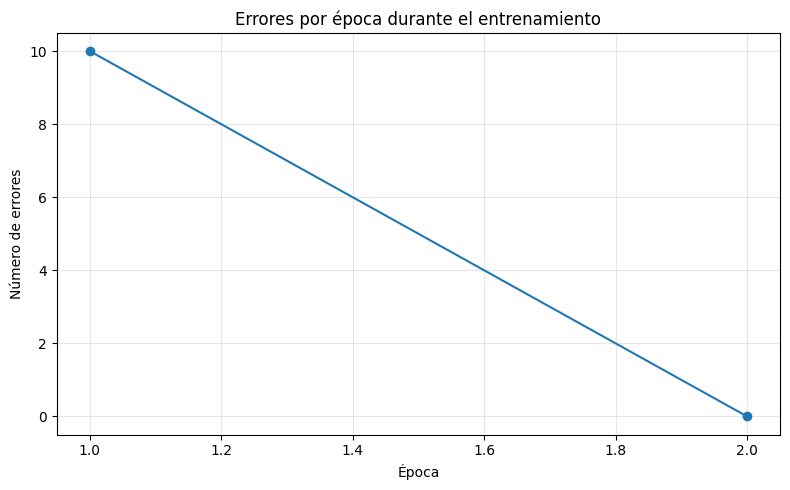

In [ ]:
"""Grafica la evolución de errores por época durante el entrenamiento."""

plot_error_history(errors, OUTPUT_GRAPHS / "errores_por_epoca.png")


## 8. Prueba del perceptrón entrenado

Ahora se evalúa el mismo dataset usando los pesos y el sesgo aprendidos.


In [ ]:
"""Evalúa el perceptrón entrenado sobre el conjunto de entrenamiento."""

z_final = model.decision_scores(X_train)
y_final = model.predict(X_train)
final_accuracy = accuracy_score(y_train, y_final)

print(f"Exactitud con entrenamiento: {final_accuracy:.2%}")
print(confusion_counts(y_train, y_final))


Exactitud con entrenamiento: 100.00%
{'TP': 8, 'TN': 22, 'FP': 0, 'FN': 0}


In [ ]:
"""Construye una tabla comparativa entre predicciones sin entrenamiento y con entrenamiento."""

final_results = build_results_table(
    train_df,
    z_final,
    y_final,
    target_column="y_pasa_entrevista",
    prediction_column="y_pred_entrenado",
    z_column="z_entrenado",
)

comparison_df = final_results.copy()
comparison_df["z_sin_entrenamiento"] = z_initial
comparison_df["y_pred_sin_entrenamiento"] = y_initial
comparison_df[[
    "id",
    "candidato",
    "x1_experiencia_norm",
    "x2_puntaje_norm",
    "cumple_experiencia",
    "cumple_puntaje",
    "y_pasa_entrevista",
    "z_sin_entrenamiento",
    "y_pred_sin_entrenamiento",
    "z_entrenado",
    "y_pred_entrenado",
]]


,id,candidato,x1_experiencia_norm,x2_puntaje_norm,cumple_experiencia,cumple_puntaje,y_pasa_entrevista,z_sin_entrenamiento,y_pred_sin_entrenamiento,z_entrenado,y_pred_entrenado
0,1,Candidato 01,0.12,0.45,0,0,0,0.0,1,-2.000000e-01,0
1,2,Candidato 02,0.25,0.68,0,0,0,0.0,1,-2.000000e-01,0
2,3,Candidato 03,0.38,0.72,0,1,0,0.0,1,-1.000000e-01,0
3,4,Candidato 04,0.50,0.69,0,0,0,0.0,1,-2.000000e-01,0
4,5,Candidato 05,0.62,0.75,0,1,0,0.0,1,-1.000000e-01,0
5,6,Candidato 06,0.75,0.80,1,1,1,0.0,1,1.000000e-01,1
6,7,Candidato 07,1.00,0.90,1,1,1,0.0,1,1.000000e-01,1
7,8,Candidato 08,0.20,0.88,0,1,0,0.0,1,-1.000000e-01,0
8,9,Candidato 09,1.00,0.60,1,0,0,0.0,1,-2.775558e-17,0
9,10,Candidato 10,1.00,0.95,1,1,1,0.0,1,1.000000e-01,1


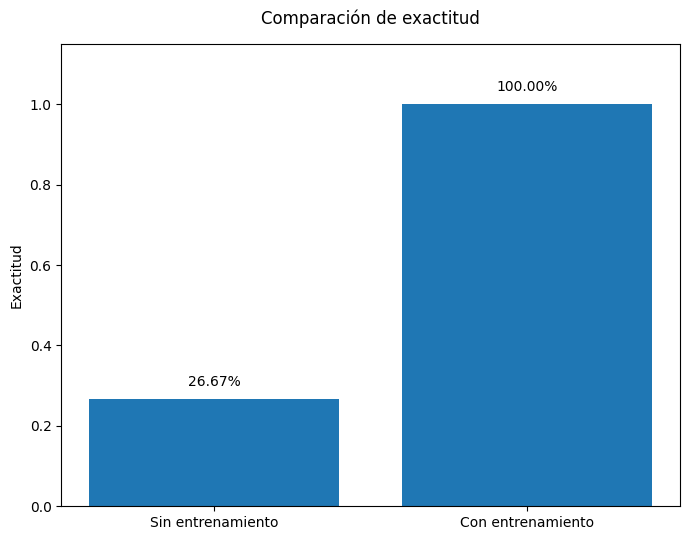

In [ ]:
"""Grafica la comparación de exactitud antes y después del entrenamiento."""

plot_accuracy_comparison(
    initial_accuracy,
    final_accuracy,
    OUTPUT_GRAPHS / "comparacion_exactitud.png",
)


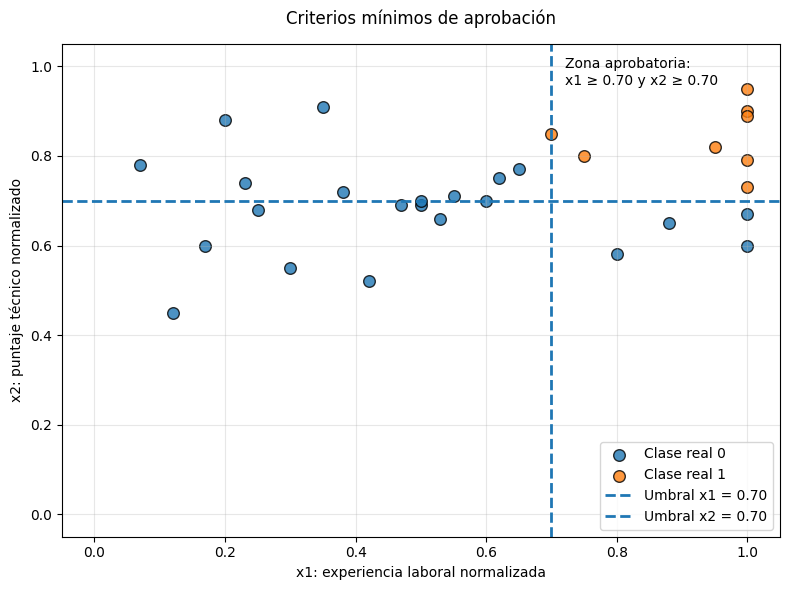

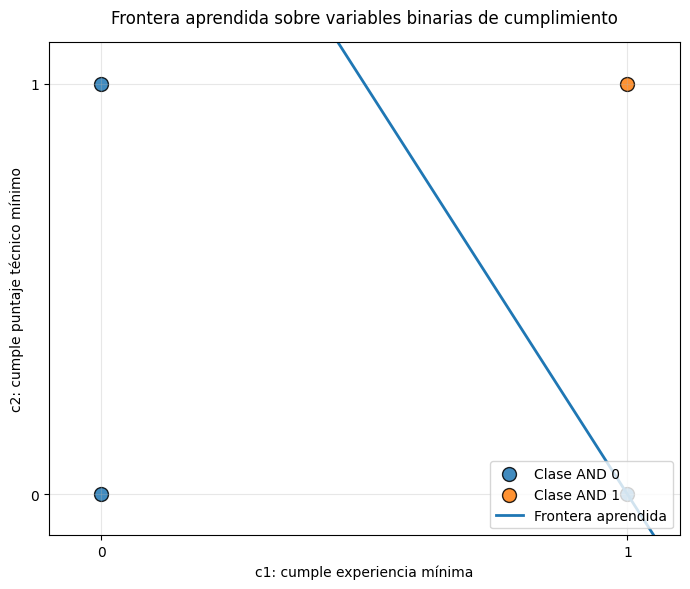

In [ ]:
"""Genera las gráficas de criterios mínimos y frontera aprendida."""

plot_minimum_criteria(
    train_df,
    OUTPUT_GRAPHS / "criterios_minimos_aprobacion.png",
    threshold=MIN_APPROVAL_THRESHOLD,
)

plot_learned_and_boundary(
    model.weights,
    model.bias,
    OUTPUT_GRAPHS / "frontera_and_aprendida.png",
)


## 9. Prueba con 10 candidatos nuevos

Se evalúan 10 casos no usados en el entrenamiento para verificar si el perceptrón aplica la regla aprendida a datos nuevos.


In [ ]:
"""Carga candidatos nuevos, aplica el modelo entrenado y calcula métricas de prueba."""

test_df = load_test_dataset(DATA_DIR / "candidatos_prueba.csv")
X_test = test_df[feature_columns].to_numpy(dtype=float)
y_test = test_df["y_esperada"].to_numpy(dtype=int)

z_test = model.decision_scores(X_test)
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Exactitud en candidatos nuevos: {test_accuracy:.2%}")
print(confusion_counts(y_test, y_test_pred))


2026-06-26 00:08:29,173 | INFO | src.dataset | Cargando dataset: /mnt/data/work_v7/perceptron_candidatos/data/candidatos_prueba.csv


2026-06-26 00:08:29,176 | INFO | src.dataset | Dataset de prueba validado: 10 registros.


Exactitud en candidatos nuevos: 100.00%
{'TP': 3, 'TN': 7, 'FP': 0, 'FN': 0}


In [ ]:
"""Construye la tabla de resultados para candidatos nuevos."""

test_results = build_results_table(
    test_df,
    z_test,
    y_test_pred,
    target_column="y_esperada",
    prediction_column="y_pred_modelo",
    z_column="z_modelo",
)
test_results


,id,candidato,anios_experiencia,puntaje_tecnico,x1_experiencia_norm,x2_puntaje_norm,cumple_experiencia,cumple_puntaje,suma_cumplimiento,y_esperada,observacion,z_modelo,y_pred_modelo,acierto_y_pred_modelo
0,1,Prueba 01,3.0,75,0.75,0.75,1,1,1.50,1,Cumple,1.000000e-01,1,True
1,2,Prueba 02,1.5,95,0.38,0.95,0,1,1.33,0,No cumple,-1.000000e-01,0,True
2,3,Prueba 03,4.0,60,1.00,0.60,1,0,1.60,0,No cumple,-2.775558e-17,0,True
3,4,Prueba 04,2.0,68,0.50,0.68,0,0,1.18,0,No cumple,-2.000000e-01,0,True
4,5,Prueba 05,2.8,72,0.70,0.72,1,1,1.42,1,Cumple,1.000000e-01,1,True
5,6,Prueba 06,0.8,88,0.20,0.88,0,1,1.08,0,No cumple,-1.000000e-01,0,True
6,7,Prueba 07,5.0,82,1.00,0.82,1,1,1.82,1,Cumple,1.000000e-01,1,True
7,8,Prueba 08,3.5,55,0.88,0.55,1,0,1.43,0,No cumple,-2.775558e-17,0,True
8,9,Prueba 09,1.0,70,0.25,0.70,0,1,0.95,0,No cumple,-1.000000e-01,0,True
9,10,Prueba 10,2.5,65,0.62,0.65,0,0,1.27,0,No cumple,-2.000000e-01,0,True


**Comentario de resultados:**  
La prueba con candidatos nuevos confirma que el perceptrón aplica la regla aprendida a casos no usados durante el entrenamiento, manteniendo la clasificación según los mínimos definidos.


## 10. Guardado de resultados

Se guardan tablas CSV para incluirlas posteriormente en el reporte formal.


In [ ]:
"""Guarda las tablas de resultados generadas por la práctica."""

save_dataframe(initial_results, OUTPUT_TABLES / "resultados_sin_entrenamiento.csv")
save_dataframe(comparison_df, OUTPUT_TABLES / "resultados_con_entrenamiento.csv")
save_dataframe(test_results, OUTPUT_TABLES / "resultados_candidatos_prueba.csv")

print("Resultados guardados.")


2026-06-26 00:08:29,205 | INFO | src.evaluation | Tabla guardada en: /mnt/data/work_v7/perceptron_candidatos/outputs/tablas/resultados_sin_entrenamiento.csv


2026-06-26 00:08:29,206 | INFO | src.evaluation | Tabla guardada en: /mnt/data/work_v7/perceptron_candidatos/outputs/tablas/resultados_con_entrenamiento.csv


2026-06-26 00:08:29,208 | INFO | src.evaluation | Tabla guardada en: /mnt/data/work_v7/perceptron_candidatos/outputs/tablas/resultados_candidatos_prueba.csv


Resultados guardados.


## 11. Conclusiones

1. El perceptrón sin entrenamiento no representa una regla aprendida; sus predicciones dependen de pesos y sesgo iniciales.
2. El entrenamiento ajusta pesos y sesgo mediante el error hasta aprender la regla definida.
3. La aprobación exige cumplimiento simultáneo: `x1 >= 0.70` y `x2 >= 0.70`.
4. El modelo entrenado clasificó correctamente el conjunto de entrenamiento y los candidatos nuevos.


## 12. Reflexión final

El perceptrón de Frank Rosenblatt es relevante porque representa una de las unidades binarias más simples del aprendizaje automático: recibe entradas, calcula una combinación ponderada y produce una decisión de clase `0` o `1`. Aunque su capacidad se limita a problemas linealmente separables, permite comprender la base del aprendizaje supervisado: comparar una predicción con una salida esperada, medir el error y ajustar pesos para mejorar el desempeño.

Por ello, el perceptrón funciona como punto de partida conceptual para estudiar modelos más avanzados de clasificación y redes neuronales.


## 13. Referencias Bibliográficas

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press.

Rosenblatt, F. (1958). The perceptron: A probabilistic model for information storage and organization in the brain. *Psychological Review, 65*(6), 386–408.

Russell, S. J., & Norvig, P. (2022). *Artificial intelligence: A modern approach* (4th ed., Global ed.). Pearson.


## 14. Recursos EdTech de Machine Learning

1. [Perceptrón de Frank Rosenblatt Interactivo](https://perceptronfrankrosenblatt.streamlit.app/)  
   Nota de acceso: clicar **Yes, get this app back up!**

2. [Explorador interactivo de Machine Learning](https://antoniot73.shinyapps.io/ml-tipos-aprendizaje/)  
   Nota de acceso: clicar **Disconnected from the server. Reload**
